## 1. Imports

In [2]:
# import arviz as az
import matplotlib.pyplot as plt
import numpy as np
# import pymc as pm
# import pytensor
# import pytensor.tensor as pt

# from pytensor.graph import Apply, Op

from numba import njit, prange

from scipy import optimize

from scipy.special import iv, ive

import time

# print(f"Running on PyMC v{pm.__version__}")

## 2. Log likelihood of a timeseries using bridges + simulation function defs

In [3]:
@njit
def random_numbers_for_bridges(NB, cols, seed_value):
    np.random.seed(seed_value)
    return np.random.random(size=(NB, cols))

def BDM_step(X0, k, mu, D, dt, timestepsperpoint):
    t = np.linspace(0, timestepsperpoint - 1, timestepsperpoint)
    X = np.zeros(timestepsperpoint)
    X[0] = X0

    dW = D * np.random.normal(size=timestepsperpoint)

    #Euler-Maruyama iteration
    for i in range(1,timestepsperpoint):
        X[i] = X[i-1] + k * (mu - X[i-1]) * dt + np.sqrt(X[i-1]) * dW[i-1]

    return X[-1]

def BDM_simulate_ts(X0, k, mu, D, dt, timestepsperpoint, N):
    datapoints = np.zeros(N)
    datapoints[0] = X0

    for idx in range(1,N):
        datapoints[idx] = BDM_step(datapoints[idx-1], k, mu, D, dt, timestepsperpoint)

    return datapoints

def SLM_step(X0, k, mu, D, dt, timestepsperpoint):
    t = np.linspace(0, timestepsperpoint - 1, timestepsperpoint)
    X = np.zeros(timestepsperpoint)
    X[0] = X0

    dW = D * np.random.normal(size=timestepsperpoint)

    #Euler-Maruyama iteration
    for i in range(1,timestepsperpoint):
        X[i] = X[i-1] + k * X[i-1] * (mu - X[i-1]) * dt + X[i-1] * dW[i-1]

    return X[-1]

def SLM_simulate_ts(X0, k, mu, D, dt, timestepsperpoint, N):
    datapoints = np.zeros(N)
    datapoints[0] = X0

    for idx in range(1,N):
        datapoints[idx] = SLM_step(datapoints[idx-1], k, mu, D, dt, timestepsperpoint)

    return datapoints

def simulate_timeseries(model='BDM', params=None):
    
    valid_models = {"BDM", "SLM"}
    X0, k, mu, D, dt, timestepsperpoint, N = params

    if params == None:
        raise ValueError("No parameters passed to simulate_timeseries()!")
    
    if model not in valid_models:
        raise ValueError(f"Invalid model: {model}. Must be one of: {', '.join(valid_models)}")
    elif model == 'BDM':
        sim_data = BDM_simulate_ts(X0, k, mu, D, dt, timestepsperpoint, N)
    elif model == 'SLM':
        sim_data = SLM_simulate_ts(X0, k, mu, D, dt, timestepsperpoint, N)
    return sim_data

@njit
def BDM_Lamperti(ts_data):
    arr = ts_data      
    # Check for negative values
    if np.any(arr < 0):
        raise ValueError("Input array contains negative values. Square root is not defined for negative numbers.")    
    result = 2 * np.sqrt(arr)
    return result   

@njit
def SLM_Lamperti(ts_data):
    arr = ts_data      
    # Check for negative values
    if np.any(arr < 0):
        raise ValueError("Input array contains negative values. Log is not defined for negative numbers.")    
    result = np.log(arr)
    return result

@njit
def bridge(NB, bridge_steps, x_i, x_f, Delta_t_B, D, seed_value): 
    
    random_numbers = random_numbers_for_bridges(NB=NB, cols=bridge_steps-2, seed_value=seed_value)
    
    B = np.empty((NB, bridge_steps), dtype=np.float32) #to store simulated X values for bridges
    B[:, 0] = x_i
    B[:, -1] = x_f     
    for step in range(1, bridge_steps - 1): 
        #ATTENTION: Manal's script had (bridge_steps - step) * B[:, step - 1] + x_f with a PLUS!! Is this a grave typo in Javier's?
        mean_b = ((bridge_steps - step) * B[:, step - 1] + x_f ) / (bridge_steps - step + 1)        
        var_b = (D**2 * (bridge_steps - step) * Delta_t_B ) / (bridge_steps - step + 1)      
        B[:, step] = random_numbers[:, step - 1] * np.sqrt(var_b) + mean_b    
    return B

@njit
def I_hat(k, mu, B, Delta_t_B, model='BDM'):
    
    valid_models = {"BDM", "SLM"}

    # B = np.array(B)

    if B.ndim != 1:
        raise ValueError(f"Expected 1D array, but got {B.ndim}D array with shape {B.shape}")
    
    if model not in valid_models:
        raise ValueError(f"Invalid model: {model}. Must be one of: {', '.join(valid_models)}")
    elif model == 'BDM':
        Ihat = np.sum(((2 * k * mu - 0.5 * k * B**2 - 0.5) / B)**2) * Delta_t_B
    elif model == 'SLM':
        Ihat = np.sum((k * (mu - np.exp(B)) - 0.5)**2) * Delta_t_B

    return Ihat

@njit
def Gaussian_PDF(x, mean, std_dev):
    return (1 / (std_dev * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean) / std_dev)**2)

@njit
def log_RN_Derivative_BDM(B, k, mu, D, Delta_t_B, eff_dt):
    x_i = B[0]
    x_f = B[-1]

    Ihat = I_hat(k, mu, B, Delta_t_B, model='BDM')

    return (( 2 * k * mu * np.log(x_f/x_i) - 
              np.log(x_f/x_i) * 0.5 - 
              k * (x_f**2 - x_i**2) * 0.25 )/
            (D**2)) - (Ihat / ( 2 * (D**2) ) )

@njit
def log_RN_Derivative_SLM(B, k, mu, D, Delta_t_B, eff_dt):
    x_i = B[0]
    x_f = B[-1]

    Ihat = I_hat(k, mu, B, Delta_t_B, model='SLM')

    return (((k * mu - 0.5)*(x_f - x_i) - 
             k*(np.exp(x_f) - np.exp(x_i))
            ) / 
            (D**2)) - (Ihat / (2 * (D**2)))

@njit
def log_RN_Derivative(B, k, mu, D, Delta_t_B, eff_dt, model='BDM'):
    valid_models = {"BDM", "SLM"}

    if model not in valid_models:
        raise ValueError(f"Invalid model: {model}. Must be one of: {', '.join(valid_models)}")
    elif model == 'BDM':
        return log_RN_Derivative_BDM(B, k, mu, D, Delta_t_B, eff_dt)
    elif model == 'SLM':
        return log_RN_Derivative_SLM(B, k, mu, D, Delta_t_B, eff_dt)

@njit(parallel=True)
def logRND_each_bridge(bridges, k, mu, D, Delta_t_B, eff_dt, model='BDM'):

    # Pre-allocate the result array with the correct size
    n_bridges = len(bridges)
    logRND_array = np.empty(n_bridges)  # Pre-allocate
    
    # #Array of L_t for each bridge
    # logRND_array = np.array([])

    #For each bridge, calculate L and append to array
    for i in prange(n_bridges):
        bridge = bridges[i]
        logRND_array[i] = log_RN_Derivative(bridge, k, mu, D, Delta_t_B, eff_dt, model)

    return logRND_array

@njit
def est_log_propagator(bridges, k, mu, D, Delta_t_B, eff_dt, NB, x_i, x_f, model='BDM'):
    logRND_array = logRND_each_bridge(bridges, k, mu, D, Delta_t_B, eff_dt, model)
    lL_star = np.max(logRND_array)
    G = Gaussian_PDF(x_f, x_i, eff_dt)
    return lL_star + np.log(G) - np.log(NB) + np.log(np.sum(np.exp(logRND_array - lL_star)))

@njit(parallel=True)
def log_propagators_transformed_data(data, NB, bridge_steps, Delta_t_B, D, k, mu, seed_array, model='BDM'):

    # Pre-allocate result array
    n_pairs = len(data) - 1
    log_rho_array = np.empty(n_pairs)  # Pre-allocate with correct size

    for i in prange(n_pairs):
        x_i = data[i]
        x_f = data[i + 1]
        seed_value = seed_array[i]
        
        bridges = bridge(NB, bridge_steps, x_i, x_f, Delta_t_B, D, seed_value)
        log_propagator = est_log_propagator(bridges, k, mu, D, Delta_t_B, eff_dt, NB, x_i, x_f, model)
        # log_rho_array = np.append(log_rho_array, log_propagator)
        log_rho_array[i] = log_propagator

    return log_rho_array

@njit
def log_propagators_target_process(log_rho_array, data, model='BDM'):
    valid_models = {"BDM", "SLM"}

    data = data[1:]

    if model not in valid_models:
        raise ValueError(f"Invalid model: {model}. Must be one of: {', '.join(valid_models)}")
    elif model == 'BDM':
        h_prime = 1 / np.sqrt(data)
        log_h_prime = np.log(h_prime)
        return log_h_prime + log_rho_array
    elif model == 'SLM':
        h_prime = 1 / data
        log_h_prime = np.log(h_prime)
        return log_h_prime + log_rho_array

@njit
def ts_logL(log_rho_array, p0):
    return np.sum(log_rho_array) + np.log(p0)
    
def full_logL_pipeline(sim_data, NB, bridge_steps, Delta_t_B, D, k, mu, seed_array, model_code=0):
    
    models = ['BDM', 'SLM']
    model = models[model_code]

    if model == 'BDM':
        lamperti_tf_data = BDM_Lamperti(sim_data)   
    elif model == 'SLM':
        lamperti_tf_data = SLM_Lamperti(sim_data)

    log_rho_tilde_array = log_propagators_transformed_data(
        lamperti_tf_data, NB, bridge_steps, Delta_t_B, D, k, mu, seed_array, model
    )
    
    timeseries_logL = ts_logL(log_propagators_target_process(log_rho_tilde_array, sim_data, model), 1.0)
    
    return timeseries_logL

### 2.1. Compiling Numba

Numba compiles the decorated functions the first time it is called. We do this here, before any significant code is run.

In [4]:
# Parameters

MODEL = 'BDM'
model_code = 0

X0 = 1632
k = 1
mu = 1632
T = 100 #timeseries timespan, starts at 0 and ends at T
eff_dt = 1 #timestep of the datapoints
dt = eff_dt * 1e-3 #timestep of the simulation
real_sigma = 0.54 #real sigma such that D = sqrt(sigma / tau) = sqrt (k * sigma)
D = np.sqrt(real_sigma * k)
N = round(T+1 / eff_dt) #number of datapoints
timestepsperpoint = round(eff_dt / dt)

NB = 1000  # Number of bridges per transition
timestep_ratio = 1e3 # dt / Dt
bridge_steps = int(timestep_ratio) # Number of time steps inside bridge
Delta_t_B = eff_dt / bridge_steps 
datapoint_times = np.linspace(0, T, N)

seed=333
seed_array=np.random.default_rng(seed=seed).integers(1, 5000, size=N-1)

In [5]:
sim_data = simulate_timeseries(model=MODEL, params=(X0, k, mu, D, dt, timestepsperpoint, N))

In [6]:
print(len(sim_data)-1)

100


In [7]:
print(len(seed_array))

100


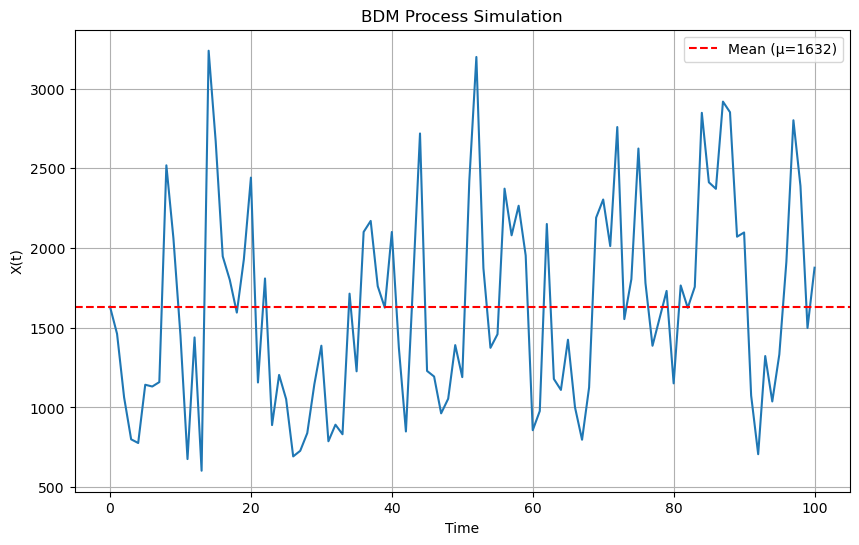

In [8]:
# Plot result
plt.figure(figsize=(10, 6))
timepoints = np.linspace(0, T, N)
plt.plot(timepoints, sim_data)
plt.axhline(y=mu, color='r', linestyle='--', label=f'Mean (μ={mu})')
plt.xlabel('Time')
plt.ylabel('X(t)')
plt.title(f'{MODEL} Process Simulation')
plt.legend()
plt.grid(True)
plt.show()

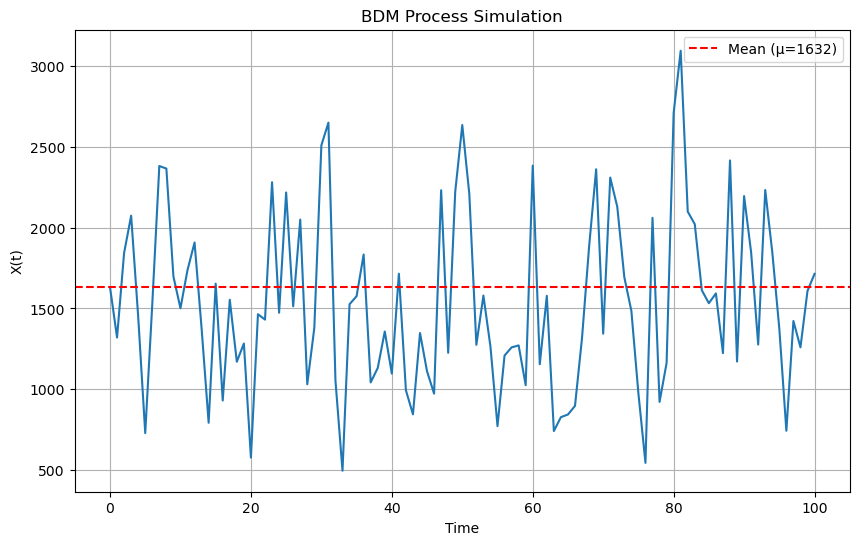

In [9]:
sim_data = simulate_timeseries(model=MODEL, params=(X0, k, mu, D, dt, timestepsperpoint, N))
# Plot result
plt.figure(figsize=(10, 6))
timepoints = np.linspace(0, T, N)
plt.plot(timepoints, sim_data)
plt.axhline(y=mu, color='r', linestyle='--', label=f'Mean (μ={mu})')
plt.xlabel('Time')
plt.ylabel('X(t)')
plt.title(f'{MODEL} Process Simulation')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
loglogl = full_logL_pipeline(sim_data, NB, bridge_steps, Delta_t_B, D, k, mu, seed_array, model_code)
print(loglogl)

-inf


## MLE of $\mu$ via optimization of estimated loglikelihood

In [11]:
def neg_loglike(mu_scalar):
    # mu_scalar comes in as a 1-D float from the optimiser
    return -full_logL_pipeline(
        sim_data, NB, bridge_steps, Delta_t_B, D, k, float(mu_scalar),
        seed_array, model_code
    )
    
starttime = time.time()

result = optimize.minimize_scalar(
    neg_loglike,
    bounds=(150.0, 160.0),      # <-- put sensible bounds for μ
    method='bounded',
    options={'xatol': 1e-3}  # convergence tolerance
)

mle_mu  = result.x
max_logL = -result.fun
print(f"MLE(mu) ≃ {mle_mu:.4f},   log-L = {max_logL:.3f}")

endtime = time.time()

print(f"Total runtime of the program is {endtime - starttime} seconds")

MLE(mu) ≃ 159.9993,   log-L = -inf
Total runtime of the program is 8.90874433517456 seconds


In [12]:
print(np.mean(sim_data))

1538.2935178886528


## Exact MLE for the BDM

#### with ive()

In [13]:
def exactLogLikelihoodBDM_transition(x_i, x_f, dt, mu, k, D):

    t = dt
    
    term1 = (k*mu / D**2) * np.log(k / D**2) + (k * mu / D**2 - 1) * np.log(x_f) - x_f*k/D**2
    term2 = (0.5 - k * mu / (2*D**2)) * np.log( (k / D**2) ** 2 * x_i * x_f * np.exp(-k * t) ) - np.log(1 - np.exp(-k*t))
    term3 = - ( k/D**2 * (x_f+x_i) * np.exp(- k * t) ) / (1 - np.exp(-k * t))
    bessel_fc_arg = ( 2 * k / D**2 * np.sqrt(x_i * x_f * np.exp (- k * t)) ) / (1 - np.exp(- k * t))
    term4 = bessel_fc_arg + np.log(ive( (k * mu / D**2 - 1) , bessel_fc_arg ) )

    print(f"bessel_fc_arg: {bessel_fc_arg}")
    print(f"k * mu / D**2 : {k * mu / D**2}")
    print(f"ive: {ive((k * mu / D**2 - 1) , bessel_fc_arg)}")
    
    
    return term1 + term2 + term3 + term4

def exactLogLikelihoodBDM_timeseries(data, mu, k, D, dt):
    
    n_pairs = len(data) - 1
    log_rho_array = np.empty(n_pairs)

    for i in range(n_pairs):
        x_i = data[i]
        x_f = data[i + 1]
        log_rho_array[i] = exactLogLikelihoodBDM_transition(x_i, x_f, dt, mu, k, D)
        if np.isinf(log_rho_array[i]):
            print(x_i, x_f, dt, mu, k, D)
            raise ValueError

    return np.sum(log_rho_array)

In [14]:
print(exactLogLikelihoodBDM_timeseries(sim_data, mu, k, D, eff_dt))

/tmp/ipykernel_1234977/2449902537.py:9: RuntimeWarning: divide by zero encountered in log
  term4 = bessel_fc_arg + np.log(ive( (k * mu / D**2 - 1) , bessel_fc_arg ) )


bessel_fc_arg: 5215.22192037888
k * mu / D**2 : 3022.222222222222
ive: 0.0
1632.0 1319.6150909334388 1 1632 1 0.7348469228349535


ValueError: 

MLE with the exact likelihood function and ive()

In [15]:
def neg_loglike(mu_scalar):
    # mu_scalar comes in as a 1-D float from the optimiser
    return -exactLogLikelihoodBDM_timeseries(sim_data, mu_scalar, k, D, eff_dt)
    
    
starttime = time.time()

result = optimize.minimize_scalar(
    neg_loglike,
    bounds=(20.0, 340.0),      # <-- put sensible bounds for μ
    method='bounded',
    options={'xatol': 1e-3}  # convergence tolerance
)

mle_mu  = result.x
max_logL = -result.fun
print(f"MLE(mu) ≃ {mle_mu:.4f},   log-L = {max_logL:.3f}")

endtime = time.time()

print(f"Total runtime of the program is {endtime - starttime} seconds")

bessel_fc_arg: 5215.22192037888
k * mu / D**2 : 263.3872659259882
ive: 7.516474635671077e-06
bessel_fc_arg: 5542.766646390256
k * mu / D**2 : 263.3872659259882
ive: 1.0767536379634043e-05
bessel_fc_arg: 6948.908939780119
k * mu / D**2 : 263.3872659259882
ive: 3.377927011707254e-05
bessel_fc_arg: 6161.193702772558
k * mu / D**2 : 263.3872659259882
ive: 1.9045220810685293e-05
bessel_fc_arg: 3649.9624297805944
k * mu / D**2 : 263.3872659259882
ive: 5.309608021986353e-07
bessel_fc_arg: 3745.2709310978926
k * mu / D**2 : 263.3872659259882
ive: 6.661829149642528e-07
bessel_fc_arg: 6775.080082324695
k * mu / D**2 : 263.3872659259882
ive: 3.0127615596208454e-05
bessel_fc_arg: 8436.647047378401
k * mu / D**2 : 263.3872659259882
ive: 7.342500223962187e-05
bessel_fc_arg: 7122.887367451019
k * mu / D**2 : 263.3872659259882
ive: 3.7654623187733604e-05
bessel_fc_arg: 5672.989289235127
k * mu / D**2 : 263.3872659259882
ive: 1.2273387457268768e-05
bessel_fc_arg: 5738.980016032058
k * mu / D**2 : 263.3

In [16]:
np.mean(sim_data)

np.float64(1538.2935178886528)

## 5. True Parameters

In [17]:
# Parameters

MODEL = 'BDM'
model_code = 0

X0 = 1632
k = 1
mu = 1632
T = 100 #timeseries timespan, starts at 0 and ends at T
eff_dt = 1 #timestep of the datapoints
dt = eff_dt * 1e-3 #timestep of the simulation
real_sigma = 0.54 #real sigma such that D = sqrt(sigma / tau) = sqrt (k * sigma)
D = np.sqrt(real_sigma * k)
N = round(T+1 / eff_dt) #number of datapoints
timestepsperpoint = round(eff_dt / dt)

NB = 1000  # Number of bridges per transition
timestep_ratio = 1e3 # dt / Dt
bridge_steps = int(timestep_ratio) # Number of time steps inside bridge
Delta_t_B = eff_dt / bridge_steps 
datapoint_times = np.linspace(0, T, N)

seed=333
seed_array=np.random.default_rng(seed=seed).integers(1, 5000, size=N-1)

### 5.1. Likelihood function evaluation parameters

In [18]:
how_many_timeseries = 30 #how many timeseries per sample size N

eff_dt_list = [1, 0.5, 0.25, 0.125, 0.0625, 0.03125, 0.0156, 0.007]
#corresponding to
N_array = np.zeros(len(eff_dt_list))
N_array[:] = T+1
N_array = np.round(N_array / eff_dt_list) #number of datapoints
print(N_array)

[  101.   202.   404.   808.  1616.  3232.  6474. 14429.]


## 6. Evaluate likelihood estimate for the BDM

In [19]:
#each row will correspond to a specified sample size, each column will correspond to a specific timeseries
est_likelihoods_array = np.zeros((len(eff_dt_list) , how_many_timeseries))
real_likelihoods_array = np.zeros((len(eff_dt_list) , how_many_timeseries))

In [20]:
for eff_dt, N in zip(eff_dt_list, N_array):
    print(f"{eff_dt} and {N}")

1 and 101.0
0.5 and 202.0
0.25 and 404.0
0.125 and 808.0
0.0625 and 1616.0
0.03125 and 3232.0
0.0156 and 6474.0
0.007 and 14429.0


In [21]:
for idx, (eff_dt, N) in enumerate(zip(eff_dt_list, N_array)):
    N = int(N)

    dt = eff_dt * 1e-3 #timestep of the simulation
    timestepsperpoint = round(eff_dt / dt)
    NB = 1000  # Number of bridges per transition
    timestep_ratio = 1e3 # dt / Dt
    bridge_steps = int(timestep_ratio) # Number of time steps inside bridge
    Delta_t_B = eff_dt / bridge_steps 
    datapoint_times = np.linspace(0, T, N)
    seed=333
    seed_array=np.random.default_rng(seed=seed).integers(1, 5000, size=N-1)

    for simulation_idx in range(how_many_timeseries):
        sim_data = simulate_timeseries(model=MODEL, params=(X0, k, mu, D, dt, timestepsperpoint, N))
        est_likelihoods_array[idx, simulation_idx] = full_logL_pipeline(
            sim_data, NB, bridge_steps, Delta_t_B, D, k, mu, seed_array, model_code)
        real_likelihoods_array[idx, simulation_idx] = exactLogLikelihoodBDM_timeseries(sim_data, mu, k, D, eff_dt)    

bessel_fc_arg: 5211.656466887832
k * mu / D**2 : 3022.222222222222
ive: 0.0
1632.0 1317.8113640820063 1 1632 1 0.7348469228349535


/tmp/ipykernel_1234977/2449902537.py:9: RuntimeWarning: divide by zero encountered in log
  term4 = bessel_fc_arg + np.log(ive( (k * mu / D**2 - 1) , bessel_fc_arg ) )


ValueError: 

/tmp/ipykernel_1234977/82802230.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


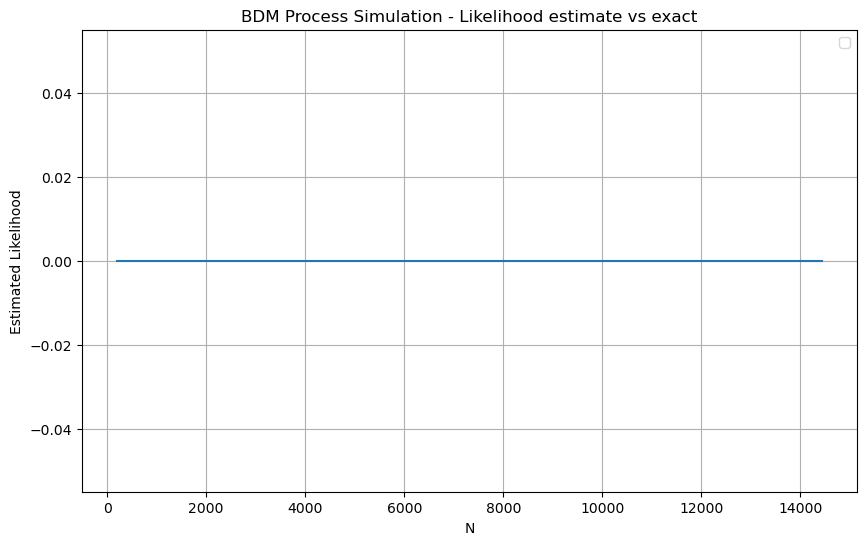

In [22]:
# Plot result
plt.figure(figsize=(10, 6))

x_coords = N_array
y_coords = est_likelihoods_array[:,0]

plt.plot(x_coords, y_coords)
plt.xlabel('N')
plt.ylabel('Estimated Likelihood')
plt.title(f'{MODEL} Process Simulation - Likelihood estimate vs exact')
plt.legend()
plt.grid(True)
plt.show()

### Plot estimated likelihood as a function of NB

In [23]:
# Parameters

MODEL = 'BDM'
model_code = 0

X0 = 1
k = 1
mu = 1
T = 100 #timeseries timespan, starts at 0 and ends at T
eff_dt = 1 #timestep of the datapoints
dt = eff_dt * 1e-3 #timestep of the simulation
real_sigma = 5.4 #real sigma such that D = sqrt(sigma / tau) = sqrt (k * sigma)
D = np.sqrt(real_sigma * k)
N = round(T+1 / eff_dt) #number of datapoints
timestepsperpoint = round(eff_dt / dt)

NB = 1000  # Number of bridges per transition
timestep_ratio = 1e3 # dt / Dt
bridge_steps = int(timestep_ratio) # Number of time steps inside bridge
Delta_t_B = eff_dt / bridge_steps 
datapoint_times = np.linspace(0, T, N)

seed=333
seed_array=np.random.default_rng(seed=seed).integers(1, 5000, size=N-1)

/tmp/ipykernel_1234977/2456640385.py:15: RuntimeWarning: invalid value encountered in sqrt
  X[i] = X[i-1] + k * (mu - X[i-1]) * dt + np.sqrt(X[i-1]) * dW[i-1]


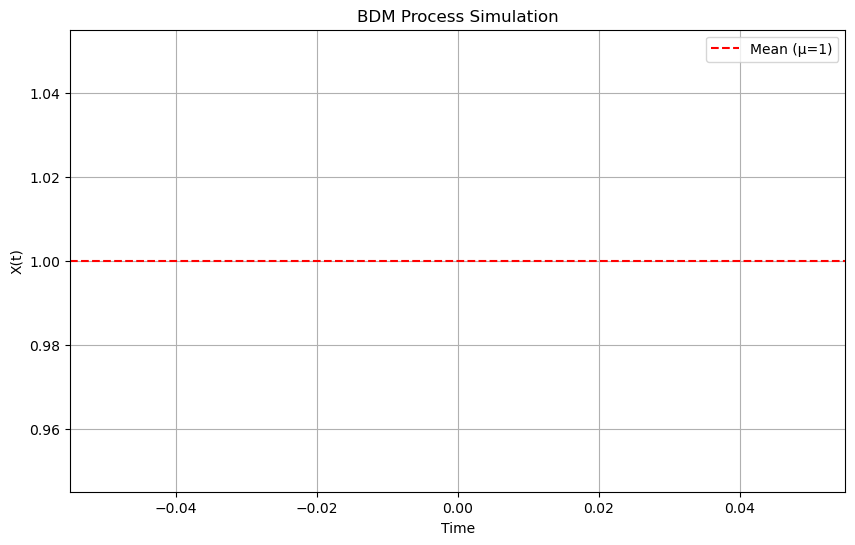

In [24]:
sim_data = simulate_timeseries(model=MODEL, params=(X0, k, mu, D, dt, timestepsperpoint, N))
# Plot result
plt.figure(figsize=(10, 6))
timepoints = np.linspace(0, T, N)
plt.plot(timepoints, sim_data)
plt.axhline(y=mu, color='r', linestyle='--', label=f'Mean (μ={mu})')
plt.xlabel('Time')
plt.ylabel('X(t)')
plt.title(f'{MODEL} Process Simulation')
plt.legend()
plt.grid(True)
plt.show()

In [25]:
print(full_logL_pipeline(sim_data, NB, bridge_steps, Delta_t_B, D, k, mu, seed_array, model_code))

nan


In [26]:
NB_array = list(range(500, 10000, 500))
est_log_likelihoods_array = [full_logL_pipeline(sim_data, NB, bridge_steps, Delta_t_B, D, k, mu, seed_array, model_code) for NB in NB_array]
real_log_likelihood = exactLogLikelihoodBDM_timeseries(sim_data, mu, k, D, eff_dt) 

KeyboardInterrupt: 

In [ ]:
print(exactLogLikelihoodBDM_timeseries(sim_data, mu, k, D, eff_dt))

In [276]:
print(exactLogLikelihoodBDM_transition(95.74833296223446, 53.22492027621822, 1, 500, 1, 0.7348469228349535))

bessel_fc_arg: 253.69517061775116
k * mu / D**2 : 925.9259259259259
ive: 0.0
-inf


/tmp/ipykernel_23669/2449902537.py:9: RuntimeWarning: divide by zero encountered in log
  term4 = bessel_fc_arg + np.log(ive( (k * mu / D**2 - 1) , bessel_fc_arg ) )


In [27]:
print(D**2)

5.4


# Est. vs real likelihood of one transition

In [53]:
# Parameters

MODEL = 'BDM'
model_code = 0

X0 = 1
k = 1
mu = 1
T = 1 #timeseries timespan, starts at 0 and ends at T
eff_dt = 1 #timestep of the datapoints
dt = eff_dt * 1e-3 #timestep of the simulation
real_sigma = 0.54 #real sigma such that D = sqrt(sigma / tau) = sqrt (k * sigma)
D = np.sqrt(real_sigma * k)
N = round(T+1 / eff_dt) #number of datapoints
timestepsperpoint = round(eff_dt / dt)

NB = 1000  # Number of bridges per transition
timestep_ratio = 1e3 # dt / Dt
bridge_steps = int(timestep_ratio) # Number of time steps inside bridge
Delta_t_B = eff_dt / bridge_steps 
datapoint_times = np.linspace(0, T, N)

seed=333
seed_array=np.random.default_rng(seed=seed).integers(1, 5000, size=N-1)

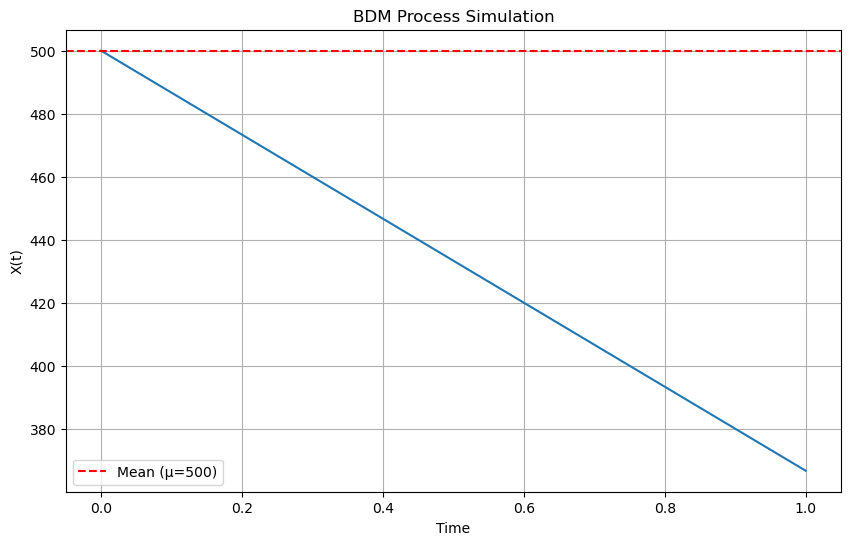

In [29]:
sim_data = simulate_timeseries(model=MODEL, params=(X0, k, mu, D, dt, timestepsperpoint, N))
# Plot result
plt.figure(figsize=(10, 6))
timepoints = np.linspace(0, T, N)
plt.plot(timepoints, sim_data)
plt.axhline(y=mu, color='r', linestyle='--', label=f'Mean (μ={mu})')
plt.xlabel('Time')
plt.ylabel('X(t)')
plt.title(f'{MODEL} Process Simulation')
plt.legend()
plt.grid(True)
plt.show()

In [30]:
exactLogLikelihoodBDM_timeseries(sim_data, mu, k, D, eff_dt)

bessel_fc_arg: 1521.8630240183745
k * mu / D**2 : 925.9259259259259
ive: 2.034648964939995e-121


np.float64(-49.17115095076542)

In [31]:
seed=133
NB=100

seed_array=np.random.default_rng(seed=seed).integers(1, 5000, size=N-1)
full_logL_pipeline(sim_data, NB, bridge_steps, Delta_t_B, D, k, mu, seed_array, model_code)

-67.55094218937906

In [55]:
how_many_transitions = 100
NB_array = list(range(100, 1000, 100))
seed=133
metaseeds = np.random.default_rng(seed=seed).integers(1,5000, size=(how_many_transitions, len(NB_array)))

est_likelihoods_array = np.zeros((how_many_transitions, len(NB_array)))
real_likelihoods_array = np.zeros((how_many_transitions, len(NB_array)))

for NB_idx, NB in enumerate(NB_array):
    for sim_idx in range(how_many_transitions):
        sim_data = np.array([1.0, 1.0])
        
        seed_array=np.array([metaseeds[sim_idx, NB_idx]])
        
        est_likelihoods_array[sim_idx , NB_idx] = full_logL_pipeline(sim_data, NB, bridge_steps, Delta_t_B, D, k, mu, seed_array, model_code)
        real_likelihoods_array[sim_idx, NB_idx] = exactLogLikelihoodBDM_timeseries(sim_data, mu, k, D, eff_dt)

bessel_fc_arg: 3.553768058027673
k * mu / D**2 : 1.8518518518518516
ive: 0.19511734121201293
bessel_fc_arg: 3.553768058027673
k * mu / D**2 : 1.8518518518518516
ive: 0.19511734121201293
bessel_fc_arg: 3.553768058027673
k * mu / D**2 : 1.8518518518518516
ive: 0.19511734121201293
bessel_fc_arg: 3.553768058027673
k * mu / D**2 : 1.8518518518518516
ive: 0.19511734121201293
bessel_fc_arg: 3.553768058027673
k * mu / D**2 : 1.8518518518518516
ive: 0.19511734121201293
bessel_fc_arg: 3.553768058027673
k * mu / D**2 : 1.8518518518518516
ive: 0.19511734121201293
bessel_fc_arg: 3.553768058027673
k * mu / D**2 : 1.8518518518518516
ive: 0.19511734121201293
bessel_fc_arg: 3.553768058027673
k * mu / D**2 : 1.8518518518518516
ive: 0.19511734121201293
bessel_fc_arg: 3.553768058027673
k * mu / D**2 : 1.8518518518518516
ive: 0.19511734121201293
bessel_fc_arg: 3.553768058027673
k * mu / D**2 : 1.8518518518518516
ive: 0.19511734121201293
bessel_fc_arg: 3.553768058027673
k * mu / D**2 : 1.8518518518518516
iv

In [56]:
est_v_real_l_difference = est_likelihoods_array - real_likelihoods_array
print(est_v_real_l_difference)

[[-4.95895614 -4.99007777 -4.97849985 -4.96988239 -4.97601908 -4.98055079
  -4.97993828 -4.9832575  -4.98558289]
 [-4.99373913 -4.99436435 -4.96814817 -4.98095915 -4.97476053 -4.98282271
  -4.97831718 -4.98306183 -4.97357517]
 [-4.98668445 -4.97519224 -4.98488321 -4.98807248 -4.98571756 -4.98800564
  -4.981365   -4.98076864 -4.97781383]
 [-4.97552375 -4.98807972 -4.97738393 -4.98647812 -4.97770371 -4.98262253
  -4.98578738 -4.98058615 -4.98245901]
 [-4.99141893 -4.96452206 -4.98676462 -4.98097177 -4.97793223 -4.98143204
  -4.98399198 -4.98297046 -4.97977082]
 [-4.97808201 -4.9914709  -4.98132815 -4.96709772 -4.98214686 -4.97590549
  -4.97928838 -4.98781965 -4.98289033]
 [-4.98640771 -4.96978472 -4.97698499 -4.98372242 -4.98822853 -4.97455248
  -4.98261705 -4.97452793 -4.97855396]
 [-4.96768701 -4.97956383 -4.98015835 -4.97273658 -4.97874668 -4.97500308
  -4.98426975 -4.97430806 -4.98698151]
 [-4.96469164 -4.97834415 -4.99005963 -4.9730693  -4.97770553 -4.97833131
  -4.97893254 -4.97858

In [57]:
avg_diff_per_NB = np.mean(est_v_real_l_difference, axis=0)
print(avg_diff_per_NB)

[-4.97799227 -4.97974453 -4.9806417  -4.98022647 -4.97925573 -4.98018096
 -4.9798379  -4.98072114 -4.98031782]


In [58]:
print(est_likelihoods_array)

[[-5.54587616 -5.57699779 -5.56541987 -5.55680241 -5.5629391  -5.56747081
  -5.5668583  -5.57017752 -5.57250291]
 [-5.58065915 -5.58128437 -5.55506819 -5.56787916 -5.56168055 -5.56974273
  -5.5652372  -5.56998185 -5.56049519]
 [-5.57360447 -5.56211225 -5.57180323 -5.5749925  -5.57263758 -5.57492566
  -5.56828502 -5.56768866 -5.56473385]
 [-5.56244377 -5.57499974 -5.56430395 -5.57339814 -5.56462373 -5.56954255
  -5.5727074  -5.56750617 -5.56937903]
 [-5.57833895 -5.55144208 -5.57368464 -5.56789179 -5.56485225 -5.56835205
  -5.570912   -5.56989048 -5.56669084]
 [-5.56500203 -5.57839092 -5.56824817 -5.55401774 -5.56906688 -5.56282551
  -5.5662084  -5.57473967 -5.56981034]
 [-5.57332773 -5.55670474 -5.56390501 -5.57064244 -5.57514855 -5.5614725
  -5.56953707 -5.56144795 -5.56547398]
 [-5.55460703 -5.56648385 -5.56707837 -5.5596566  -5.5656667  -5.5619231
  -5.57118977 -5.56122808 -5.57390153]
 [-5.55161166 -5.56526417 -5.57697965 -5.55998932 -5.56462555 -5.56525133
  -5.56585256 -5.5655090

## bridges' estimators

In [80]:
@njit
def random_numbers_for_bridges(NB, cols, seed_value):
    np.random.seed(seed_value)
    return np.random.random(size=(NB, cols))

@njit
def BDM_Lamperti(ts_data):
    arr = ts_data      
    # Check for negative values
    if np.any(arr < 0):
        raise ValueError("Input array contains negative values. Square root is not defined for negative numbers.")    
    result = 2 * np.sqrt(arr)
    return result   

@njit
def SLM_Lamperti(ts_data):
    arr = ts_data      
    # Check for negative values
    if np.any(arr < 0):
        raise ValueError("Input array contains negative values. Log is not defined for negative numbers.")    
    result = np.log(arr)
    return result

@njit
def bridge(NB, bridge_steps, x_i, x_f, Delta_t_B, D, seed_value): 
    
    random_numbers = random_numbers_for_bridges(NB=NB, cols=bridge_steps-2, seed_value=seed_value)
    
    B = np.empty((NB, bridge_steps), dtype=np.float32) #to store simulated X values for bridges
    B[:, 0] = x_i
    B[:, -1] = x_f     
    for step in range(1, bridge_steps - 1): 
        #ATTENTION: Manal's script had (bridge_steps - step) * B[:, step - 1] + x_f with a PLUS!! Is this a grave typo in Javier's?
        mean_b = ((bridge_steps - step) * B[:, step - 1] + x_f ) / (bridge_steps - step + 1)        
        var_b = (D**2 * (bridge_steps - step) * Delta_t_B ) / (bridge_steps - step + 1)      
        B[:, step] = random_numbers[:, step - 1] * np.sqrt(var_b) + mean_b    
    return B

@njit
def I_hat(k, mu, B, Delta_t_B, model='BDM'):
    
    valid_models = {"BDM", "SLM"}

    # B = np.array(B)

    if B.ndim != 1:
        raise ValueError(f"Expected 1D array, but got {B.ndim}D array with shape {B.shape}")
    
    if model not in valid_models:
        raise ValueError(f"Invalid model: {model}. Must be one of: {', '.join(valid_models)}")
    elif model == 'BDM':
        Ihat = np.sum(((2 * k * mu - 0.5 * k * B**2 - 0.5) / B)**2) * Delta_t_B
    elif model == 'SLM':
        Ihat = np.sum((k * (mu - np.exp(B)) - 0.5)**2) * Delta_t_B

    return Ihat

@njit
def Gaussian_PDF(x, mean, std_dev):
    return (1 / (std_dev * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean) / std_dev)**2)

@njit
def log_RN_Derivative_BDM(B, k, mu, D, Delta_t_B, eff_dt):
    x_i = B[0]
    x_f = B[-1]

    Ihat = I_hat(k, mu, B, Delta_t_B, model='BDM')

    return (( 2 * k * mu * np.log(x_f/x_i) - 
              np.log(x_f/x_i) * 0.5 - 
              k * (x_f**2 - x_i**2) * 0.25 )/
            (D**2)) - (Ihat / ( 2 * (D**2) ) )

@njit
def log_RN_Derivative_SLM(B, k, mu, D, Delta_t_B, eff_dt):
    x_i = B[0]
    x_f = B[-1]

    Ihat = I_hat(k, mu, B, Delta_t_B, model='SLM')

    return (((k * mu - 0.5)*(x_f - x_i) - 
             k*(np.exp(x_f) - np.exp(x_i))
            ) / 
            (D**2)) - (Ihat / (2 * (D**2)))

@njit
def log_RN_Derivative(B, k, mu, D, Delta_t_B, eff_dt, model='BDM'):
    valid_models = {"BDM", "SLM"}

    if model not in valid_models:
        raise ValueError(f"Invalid model: {model}. Must be one of: {', '.join(valid_models)}")
    elif model == 'BDM':
        return log_RN_Derivative_BDM(B, k, mu, D, Delta_t_B, eff_dt)
    elif model == 'SLM':
        return log_RN_Derivative_SLM(B, k, mu, D, Delta_t_B, eff_dt)

@njit(parallel=True)
def logRND_each_bridge(bridges, k, mu, D, Delta_t_B, eff_dt, model='BDM'):

    # Pre-allocate the result array with the correct size
    n_bridges = len(bridges)
    logRND_array = np.empty(n_bridges)  # Pre-allocate
    
    # #Array of L_t for each bridge
    # logRND_array = np.array([])

    #For each bridge, calculate L and append to array
    for i in prange(n_bridges):
        bridge = bridges[i]
        logRND_array[i] = log_RN_Derivative(bridge, k, mu, D, Delta_t_B, eff_dt, model)

    return logRND_array

# @njit
# def log_propagators_target_process(log_rho_array, data, model='BDM'):
#     valid_models = {"BDM", "SLM"}

#     data = data[1:]

#     if model not in valid_models:
#         raise ValueError(f"Invalid model: {model}. Must be one of: {', '.join(valid_models)}")
#     elif model == 'BDM':
#         h_prime = 1 / np.sqrt(data)
#         log_h_prime = np.log(h_prime)
#         return log_h_prime + log_rho_array
#     elif model == 'SLM':
#         h_prime = 1 / data
#         log_h_prime = np.log(h_prime)
#         return log_h_prime + log_rho_array

@njit
def est_log_propagator_array_target_data(bridges, k, mu, D, Delta_t_B, eff_dt, NB, x_i, x_f, model='BDM'):
    logRND_array = logRND_each_bridge(bridges, k, mu, D, Delta_t_B, eff_dt, model) #RN Derivative for each bridge
    G = Gaussian_PDF(x_f, x_i, eff_dt)
    G_arr = np.repeat(G, len(logRND_array)) #G factor for each bridge
    log_h_prime_array = np.repeat(np.log(1/np.sqrt(x_f)), len(logRND_array)) #transform each propagator back to target data
    return logRND_array + np.log(G_arr) + log_h_prime_array




# Old pipeline:

# @njit
# def log_propagators_transformed_data(data, NB, bridge_steps, Delta_t_B, D, k, mu, seed_array, model='BDM'):
#     # Pre-allocate result array
#     n_pairs = len(data) - 1
#     log_rho_array = np.empty(n_pairs)  # Pre-allocate with correct size

#     for i in prange(n_pairs):
#         x_i = data[i]
#         x_f = data[i + 1]
#         seed_value = seed_array[i]
        
#         bridges = bridge(NB, bridge_steps, x_i, x_f, Delta_t_B, D, seed_value)
#         log_propagator = est_log_propagator(bridges, k, mu, D, Delta_t_B, eff_dt, NB, x_i, x_f, model)
#         # log_rho_array = np.append(log_rho_array, log_propagator)
#         log_rho_array[i] = log_propagator

#     return log_rho_array

# @njit(parallel=True)
# def log_propagators_transformed_data(data, NB, bridge_steps, Delta_t_B, D, k, mu, seed_array, model='BDM'):

#     # Pre-allocate result array
#     n_pairs = len(data) - 1
#     log_rho_array = np.empty(n_pairs)  # Pre-allocate with correct size

#     for i in prange(n_pairs):
#         x_i = data[i]
#         x_f = data[i + 1]
#         seed_value = seed_array[i]
        
#         bridges = bridge(NB, bridge_steps, x_i, x_f, Delta_t_B, D, seed_value)
#         log_propagator = est_log_propagator(bridges, k, mu, D, Delta_t_B, eff_dt, NB, x_i, x_f, model)
#         # log_rho_array = np.append(log_rho_array, log_propagator)
#         log_rho_array[i] = log_propagator

#     return log_rho_array

# @njit
# def ts_logL(log_rho_array, p0):
#     return np.sum(log_rho_array) + np.log(p0)
    
# def full_logL_pipeline(sim_data, NB, bridge_steps, Delta_t_B, D, k, mu, seed_array, model_code=0):
    
#     models = ['BDM', 'SLM']
#     model = models[model_code]

#     if model == 'BDM':
#         lamperti_tf_data = BDM_Lamperti(sim_data)   
#     elif model == 'SLM':
#         lamperti_tf_data = SLM_Lamperti(sim_data)

#     log_rho_tilde_array = log_propagators_transformed_data(
#         lamperti_tf_data, NB, bridge_steps, Delta_t_B, D, k, mu, seed_array, model
#     )
    
#     timeseries_logL = ts_logL(log_propagators_target_process(log_rho_tilde_array, sim_data, model), 1.0)
    
#     return timeseries_logL


In [65]:
# Parameters

MODEL = 'BDM'
model_code = 0

X0 = 1
k = 1
mu = 1
T = 1 #timeseries timespan, starts at 0 and ends at T
eff_dt = 1 #timestep of the datapoints
dt = eff_dt * 1e-3 #timestep of the simulation
real_sigma = 0.54 #real sigma such that D = sqrt(sigma / tau) = sqrt (k * sigma)
D = np.sqrt(real_sigma * k)
N = round(T+1 / eff_dt) #number of datapoints
timestepsperpoint = round(eff_dt / dt)

NB = 1000  # Number of bridges per transition
timestep_ratio = 1e3 # dt / Dt
bridge_steps = int(timestep_ratio) # Number of time steps inside bridge
Delta_t_B = eff_dt / bridge_steps 
datapoint_times = np.linspace(0, T, N)

seed=333
seed_array=np.random.default_rng(seed=seed).integers(1, 5000, size=N-1)

In [81]:
data = np.array([1.0, 1.0])
lamperti_tf_data = BDM_Lamperti(data)
bridges = bridge(NB, bridge_steps, lamperti_tf_data[0], lamperti_tf_data[1], Delta_t_B, D, seed_value=4242)
log_propagator = est_log_propagator_array_target_data(bridges, k, mu, D, Delta_t_B, eff_dt, NB, 1.0, 1.0, MODEL)

In [82]:
print(log_propagator)

[-6.00932775 -5.57874378 -5.56047021 -5.49419613 -5.76372806 -5.52535964
 -5.46537217 -5.69879981 -5.62691967 -5.54167638 -5.65090307 -5.69521323
 -5.26972608 -5.51346203 -5.84775514 -5.46411401 -5.68538819 -5.6283811
 -5.55605753 -5.40621462 -5.80815951 -5.62832597 -5.40997848 -5.46810679
 -5.75885632 -5.45841964 -5.63091638 -5.85832958 -5.77286229 -5.55360261
 -5.3385002  -5.85534527 -5.6391739  -5.58854006 -5.57631614 -5.61719406
 -5.6772748  -5.71366737 -5.35563637 -5.55074467 -5.88497179 -5.40790046
 -5.46800038 -5.74505664 -5.5423076  -5.6539548  -5.4705504  -5.57963693
 -5.73215881 -5.90560422 -5.63262282 -5.60053524 -5.28866905 -5.5741814
 -5.54252554 -5.65413593 -5.86404001 -5.52197193 -5.53282684 -5.2740433
 -5.77416001 -5.69108375 -5.6552675  -5.550367   -5.29986908 -5.87612479
 -5.6246861  -5.22793298 -5.55169398 -5.70410313 -5.41284674 -5.66042626
 -5.66727736 -5.70604897 -5.73186165 -5.7267071  -5.31641271 -5.65360703
 -5.40489362 -5.51211744 -5.53698462 -5.59342686 -5.65

bessel_fc_arg: 3.553768058027673
k * mu / D**2 : 1.8518518518518516
ive: 0.19511734121201293


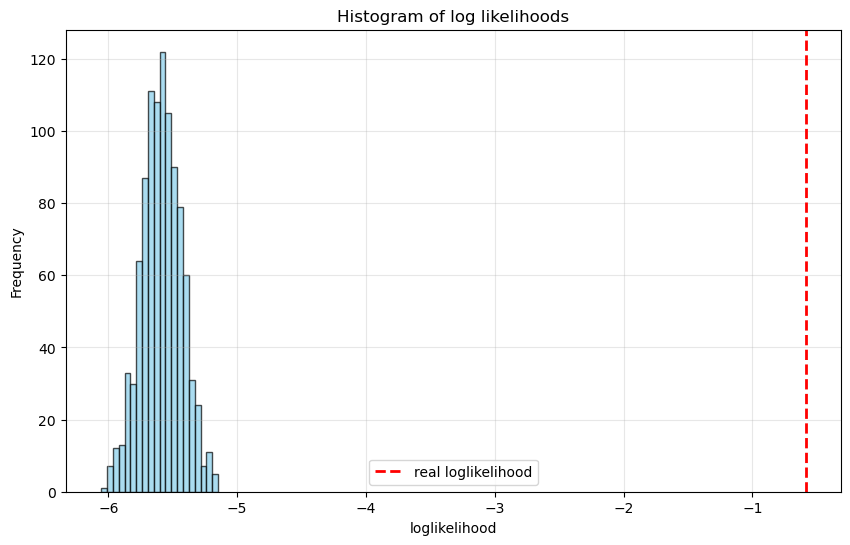

In [83]:
plt.figure(figsize=(10, 6))
plt.hist(log_propagator, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
plt.axvline(x=exactLogLikelihoodBDM_transition(1.0, 1.0, eff_dt, mu, k, D), color='red', linestyle='--', linewidth=2, label='real loglikelihood')

plt.title('Histogram of log likelihoods')
plt.xlabel('loglikelihood')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()